# Import library & Data Preparation

In [76]:
!pip install lightgbm scikit-learn

In [128]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc
)
import joblib
import os
import json
from datetime import datetime

warnings.filterwarnings("ignore")

In [79]:
# Untuk visualisasi yang lebih baik
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

In [80]:
# Set random seed untuk reproduksibilitas
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [81]:
# Load data yang sudah dipreprocess
DATA_PATH = "/kaggle/input/datasets/muhammadrafifdanuja/final-sentimen/ulasan_ovo_preprocessed_optimized.csv"
df = pd.read_csv(DATA_PATH)

print(f"Total baris      : {len(df):,}")
print(f"Kolom tersedia   : {df.columns.tolist()}\n")

Total baris      : 18,997
Kolom tersedia   : ['reviewId', 'content', 'label_final', 'text_cleaned', 'tokens', 'tokens_with_negation', 'tokens_stemmed']



In [82]:
# Cek apakah ada NaN
print("\n  Missing values:")
print(df.isnull().sum().to_string())

# Cek distribusi label
print("\n Distribusi Label:")
label_counts = df['label_final'].value_counts()
label_pct    = df['label_final'].value_counts(normalize=True) * 100
label_summary = pd.DataFrame({'Jumlah': label_counts, 'Persentase (%)': label_pct.round(2)})
print(label_summary)


  Missing values:
reviewId                0
content                 0
label_final             0
text_cleaned            0
tokens                  0
tokens_with_negation    0
tokens_stemmed          0

 Distribusi Label:
             Jumlah  Persentase (%)
label_final                        
Negatif       14154           74.51
Positif        3055           16.08
Netral         1788            9.41


Distribusi label menunjukkan ketidakseimbangan (class imbalance) yang cukup signifikan, Kondisi ini berpotensi menyebabkan model cenderung “bias” terhadap kelas mayoritas, sehingga metrik seperti accuracy bisa terlihat tinggi meskipun model kurang mampu mengenali kelas minoritas dengan baik. Oleh karena itu, dalam evaluasi model lebih tepat digunakan metrik F1-score, karena mempertimbangkan keseimbangan antara precision dan recall, sehingga memberikan gambaran performa yang lebih representatif pada dataset yang tidak seimbang dibandingkan hanya mengandalkan accuracy.

In [83]:
# Gunakan tokens_with_negation untuk fitur
# Konversi list token kembali ke string
df['text_for_model'] = df['tokens_with_negation'].apply(
    lambda x: ' '.join(x) if isinstance(x, list) else str(x)
)

In [84]:
# Encode label
le = LabelEncoder()
y  = le.fit_transform(df["label_final"])
X  = df["text_for_model"].values

print(f"Pemetaan label   : {dict(zip(le.classes_, le.transform(le.classes_)))}")
print("\nContoh teks setelah preprocessing:")
for i in range(3):
    print(f"  [{i}] {X[i][:120]}...")
    print(f"       Label asli: {df['label_final'].iloc[i]}")

Pemetaan label   : {'Negatif': np.int64(0), 'Netral': np.int64(1), 'Positif': np.int64(2)}

Contoh teks setelah preprocessing:
  [0] ['tolong', 'saldo', 'driver', 'selesaikan', 'prosesnya', 'menunggu', 'habis', 'saldo', 'dibalikin', 'saldo', 'NOT_kunjun...
       Label asli: Negatif
  [1] ['pembaruan', 'NOT_bagus', 'error']...
       Label asli: Negatif
  [2] ['buruk', 'isi', 'ulang', 'saldo', 'grab', 'diproses', 'terus-terusan']...
       Label asli: Negatif


# Data Splitting

In [85]:
# compute_class_weight('balanced') → w_c = n_samples / (n_classes * n_c)
# Kelas yang lebih sedikit akan mendapat bobot lebih besar
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # jaga proporsi label di train & test
)

print(f"Training  : {len(X_train):,} baris ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test      : {len(X_test):,} baris ({len(X_test)/len(X)*100:.1f}%)")

Training  : 15,197 baris (80.0%)
Test      : 3,800 baris (20.0%)


In [86]:
print("\nDistribusi label — training:")
print(pd.Series(y_train).value_counts())
print("\nDistribusi label — test:")
print(pd.Series(y_test).value_counts())


Distribusi label — training:
0    11323
2     2444
1     1430
Name: count, dtype: int64

Distribusi label — test:
0    2831
2     611
1     358
Name: count, dtype: int64


# TF-IDF VECTORIZATION

Dalam penelitian ini, teknik TF-IDF digunakan untuk mengubah teks menjadi fitur numerik dengan mempertimbangkan pentingnya kata berdasarkan frekuensinya dalam dokumen dan kelangkaannya di seluruh korpus. Fitur dibatasi hingga 5.000 token dengan kombinasi unigram dan bigram, serta dilakukan penyaringan kata yang terlalu jarang (min_df=2) dan terlalu umum (max_df=0.95) agar lebih relevan. Selain itu, digunakan skala logaritmik pada frekuensi kata untuk meningkatkan stabilitas, dan proses fit hanya dilakukan pada data latih guna menghindari data leakage.

In [87]:
# Catatan: fit HANYA pada train data untuk menghindari data leakage
tfidf = TfidfVectorizer(
    max_features=5000,      # ambil 5.000 token paling informatif
    ngram_range=(1, 2),     # unigram + bigram
    min_df=2,               # abaikan token yang sangat jarang (<2 dok)
    max_df=0.95,            # abaikan token yang terlalu umum (>95% dok)
    sublinear_tf=True,      # gunakan 1 + log(tf) agar skala lebih stabil
    use_idf=True,
    smooth_idf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)   # fit + transform
X_test_tfidf  = tfidf.transform(X_test)        # transform saja

In [88]:
print(f"Matriks train : {X_train_tfidf.shape}")
print(f"Matriks test  : {X_test_tfidf.shape}")
print(f"Jumlah fitur  : {len(tfidf.get_feature_names_out()):,}")

Matriks train : (15197, 5000)
Matriks test  : (3800, 5000)
Jumlah fitur  : 5,000


In [89]:
# Tampilkan 10 token dengan IDF tertinggi (paling diskriminatif)
idf_values    = tfidf.idf_
feature_names = tfidf.get_feature_names_out()
top10_idx     = np.argsort(idf_values)[-10:][::-1]
print("\n10 token IDF tertinggi:")
for idx in top10_idx:
    print(f"  {feature_names[idx]:<25} IDF = {idf_values[idx]:.4f}")


10 token IDF tertinggi:
  backhand index            IDF = 9.5303
  clapping                  IDF = 9.5303
  backhand                  IDF = 9.5303
  clapping hands            IDF = 9.5303
  downcast                  IDF = 9.5303
  nget                      IDF = 9.5303
  downcast face             IDF = 9.5303
  juara juara               IDF = 9.5303
  enggk masuk               IDF = 9.5303
  jengkel                   IDF = 9.5303


# Fungsi utilitas evaluasi

In [101]:
def evaluate_model(model, X_test, y_test, model_name: str) -> dict:
    """
    Evaluasi model klasifikasi (biner maupun multiclass).
    Menggunakan threshold default (argmax probabilitas).
    """
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None

    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall    = recall_score(y_test, y_pred, average="weighted")
    f1        = f1_score(y_test, y_pred, average="weighted")

    print(f"\n{'─'*55}")
    print(f"  HASIL EVALUASI: {model_name}")
    print(f"{'─'*55}")
    print(f"  Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
    print(f"  Precision : {precision:.4f}  (weighted)")
    print(f"  Recall    : {recall:.4f}  (weighted)")
    print(f"  F1-Score  : {f1:.4f}  (weighted)")
    print(f"\nClassification Report:\n")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    return {
        "name": model_name, "accuracy": accuracy,
        "precision": precision, "recall": recall,
        "f1": f1, "y_pred": y_pred, "y_prob": y_prob
    }

In [ ]:
def tune_threshold_multiclass(y_test, y_prob, model_name: str,
                               thresholds=None, n_steps=50) -> dict:
    """
    Cari threshold optimal per kelas dengan strategi One-vs-Rest (OvR).

    Cara kerja:
      - Untuk setiap kelas i, sweep threshold dari 0.05 hingga 0.95
      - Pilih threshold yang memaksimalkan F1-Score weighted pada test set
      - Prediksi akhir: tiap sampel → kelas dengan prob tertinggi di atas
        threshold-nya masing-masing; jika tidak ada yang lolos → kelas
        dengan prob tertinggi (fallback argmax)

    Parameter
    ---------
    y_test      : label test (integer encoded)
    y_prob      : predict_proba shape (n_samples, n_classes)
    model_name  : nama model untuk output
    thresholds  : list threshold yang ingin di-sweep (opsional)
    n_steps     : jumlah titik sweep jika thresholds tidak diberikan

    Return
    ------
    dict berisi optimal_thresholds, y_pred_tuned, accuracy, precision,
         recall, f1, threshold_history
    """
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, n_steps)

    n_classes    = y_prob.shape[1]
    best_thresh  = [0.5] * n_classes   # inisialisasi threshold per kelas
    history      = {i: {"thresholds": [], "f1": []} for i in range(n_classes)}

    print(f"\n{'='*55}")
    print(f"  THRESHOLD TUNING: {model_name}")
    print(f"{'='*55}")

    # Sweep threshold satu kelas pada satu waktu 
    for cls_idx in range(n_classes):
        best_f1     = 0.0
        best_t      = 0.5

        for t in thresholds:
            trial_thresh        = best_thresh.copy()
            trial_thresh[cls_idx] = t

            y_pred_trial = apply_threshold(y_prob, trial_thresh)
            f1_trial     = f1_score(y_test, y_pred_trial, average="weighted")

            history[cls_idx]["thresholds"].append(t)
            history[cls_idx]["f1"].append(f1_trial)

            if f1_trial > best_f1:
                best_f1 = f1_trial
                best_t  = t

        best_thresh[cls_idx] = best_t
        print(f"  Kelas '{le.classes_[cls_idx]:<12}' → threshold optimal: "
              f"{best_t:.2f}  (F1 = {best_f1:.4f})")

    # Prediksi akhir dengan threshold optimal 
    y_pred_tuned = apply_threshold(y_prob, best_thresh)

    accuracy  = accuracy_score(y_test, y_pred_tuned)
    precision = precision_score(y_test, y_pred_tuned, average="weighted")
    recall    = recall_score(y_test, y_pred_tuned, average="weighted")
    f1        = f1_score(y_test, y_pred_tuned, average="weighted")

    print(f"\n  Threshold per kelas: "
          f"{ {le.classes_[i]: round(best_thresh[i], 2) for i in range(n_classes)} }")
    print(f"\n  Hasil setelah tuning:")
    print(f"  Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
    print(f"  Precision : {precision:.4f}  (weighted)")
    print(f"  Recall    : {recall:.4f}  (weighted)")
    print(f"  F1-Score  : {f1:.4f}  (weighted)")
    print(f"\nClassification Report (tuned):\n")
    print(classification_report(y_test, y_pred_tuned, target_names=le.classes_))

    return {
        "name": model_name,
        "optimal_thresholds": {le.classes_[i]: round(best_thresh[i], 2)
                                for i in range(n_classes)},
        "y_pred_tuned": y_pred_tuned,
        "accuracy": accuracy, "precision": precision,
        "recall": recall, "f1": f1,
        "threshold_history": history
    }

In [104]:
def apply_threshold(y_prob: np.ndarray, thresholds: list) -> np.ndarray:
    """
    Terapkan threshold per kelas ke matriks probabilitas.

    Logika:
      1. Masker: True jika prob[i, cls] >= threshold[cls]
      2. Jika ≥1 kelas lolos masker → pilih kelas dengan prob tertinggi
         di antara yang lolos
      3. Jika tidak ada yang lolos (semua di bawah threshold) → fallback
         ke argmax biasa

    Parameter
    ---------
    y_prob      : np.ndarray shape (n_samples, n_classes)
    thresholds  : list threshold per kelas, panjang = n_classes

    Return
    ------
    np.ndarray shape (n_samples,) berisi prediksi kelas (integer)
    """
    thresh_arr = np.array(thresholds)
    mask       = y_prob >= thresh_arr          # (n_samples, n_classes) bool

    # Untuk sampel yang tidak ada kelas lolos → gunakan argmax sebagai fallback
    masked_prob          = y_prob.copy()
    no_class_above_thresh = ~mask.any(axis=1)
    masked_prob[~mask]   = -np.inf            # sembunyikan kelas di bawah threshold
    masked_prob[no_class_above_thresh] = y_prob[no_class_above_thresh]  # restore fallback

    return np.argmax(masked_prob, axis=1)

In [105]:
def plot_threshold_history(history: dict, model_name: str):
    """
    Visualisasi F1-Score vs Threshold untuk setiap kelas.

    Parameter
    ---------
    history    : dict dari tune_threshold_multiclass['threshold_history']
    model_name : nama model untuk judul grafik
    """
    colors = ["#534AB7", "#0F6E56", "#D85A30"]
    n_cls  = len(history)

    fig, axes = plt.subplots(1, n_cls, figsize=(5 * n_cls, 4), sharey=True)
    if n_cls == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        ts  = history[i]["thresholds"]
        f1s = history[i]["f1"]
        best_t = ts[np.argmax(f1s)]

        ax.plot(ts, f1s, color=colors[i], lw=2)
        ax.axvline(best_t, color=colors[i], linestyle="--", lw=1.5,
                   label=f"optimal = {best_t:.2f}")
        ax.set_title(f"Kelas: {le.classes_[i]}", fontsize=12)
        ax.set_xlabel("Threshold")
        ax.set_ylabel("F1-Score (weighted)" if i == 0 else "")
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)

    fig.suptitle(f"Threshold Tuning — {model_name}", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

In [106]:
def plot_confusion_matrix(y_test, y_pred, model_name: str, classes):
    """Plot confusion matrix 3×3 dengan heatmap."""
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes)
    plt.title(f"Confusion Matrix — {model_name}")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()

In [107]:
def plot_roc_curve(y_test, y_prob, model_name: str) -> dict | None:
    """
    Plot ROC Curve dengan strategi One-vs-Rest (OvR).
    """
    if y_prob is None:
        print(f"  [INFO] {model_name} tidak mendukung predict_proba.")
        return None

    n_classes  = len(le.classes_)
    y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))
    colors     = ["#534AB7", "#0F6E56", "#D85A30"]

    plt.figure(figsize=(7, 5))
    auc_scores = {}

    for i, (cls_name, color) in enumerate(zip(le.classes_, colors)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc     = auc(fpr, tpr)
        auc_scores[cls_name] = roc_auc
        plt.plot(fpr, tpr, color=color, lw=2,
                 label=f"{cls_name}  (AUC = {roc_auc:.4f})")

    plt.plot([0, 1], [0, 1], "k--", lw=1.5, label="Random classifier")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve (One-vs-Rest) — {model_name}")
    plt.legend(loc="lower right", fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return auc_scores

# Model 1 : LGBM

In [108]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=300, max_depth=15, learning_rate=0.05,
    num_leaves=31, subsample=0.8, colsample_bytree=0.8,
    min_child_samples=20, reg_alpha=0.1, reg_lambda=0.1,
    random_state=42, n_jobs=-1, verbose=-1
)

print("Training LightGBM...")
lgb_model.fit(X_train_tfidf, y_train)

Training LightGBM...


LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, max_depth=15,
               n_estimators=300, n_jobs=-1, random_state=42, reg_alpha=0.1,
               reg_lambda=0.1, subsample=0.8, verbose=-1)

In [110]:
lgb_results      = evaluate_model(lgb_model, X_test_tfidf, y_test, "LightGBM")
lgb_tuned        = tune_threshold_multiclass(y_test, lgb_results["y_prob"], "LightGBM")


───────────────────────────────────────────────────────
  HASIL EVALUASI: LightGBM
───────────────────────────────────────────────────────
  Accuracy  : 0.8661  (86.61%)
  Precision : 0.8359  (weighted)
  Recall    : 0.8661  (weighted)
  F1-Score  : 0.8380  (weighted)

Classification Report:

              precision    recall  f1-score   support

     Negatif       0.87      0.98      0.92      2831
      Netral       0.45      0.10      0.17       358
     Positif       0.90      0.80      0.84       611

    accuracy                           0.87      3800
   macro avg       0.74      0.63      0.64      3800
weighted avg       0.84      0.87      0.84      3800


  THRESHOLD TUNING: LightGBM
  Kelas 'Negatif     ' → threshold optimal: 0.47  (F1 = 0.8385)
  Kelas 'Netral      ' → threshold optimal: 0.07  (F1 = 0.8419)
  Kelas 'Positif     ' → threshold optimal: 0.49  (F1 = 0.8419)

  Threshold per kelas: {'Negatif': np.float64(0.47), 'Netral': np.float64(0.07), 'Positif': np.float6

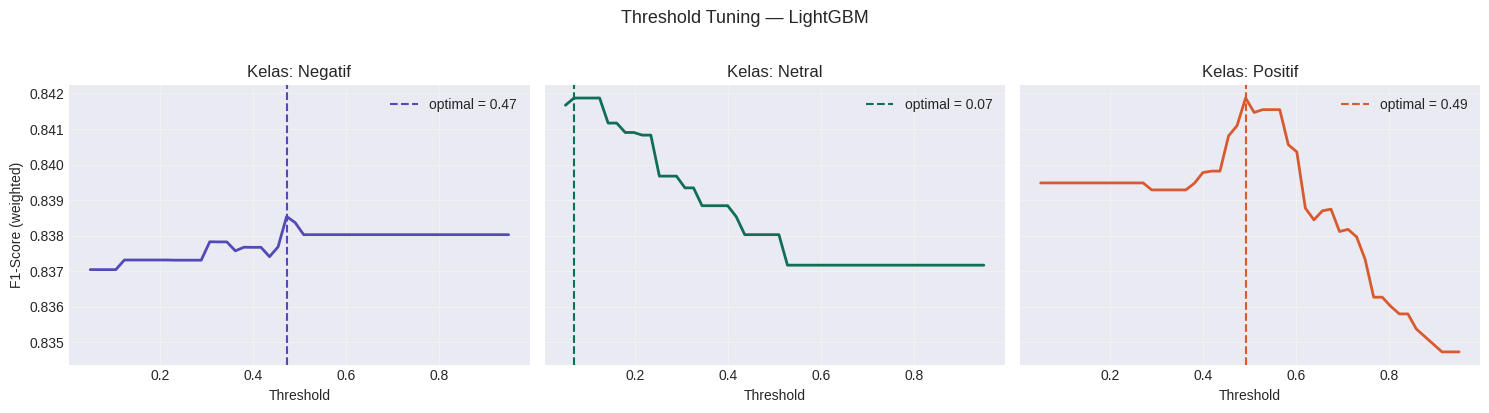

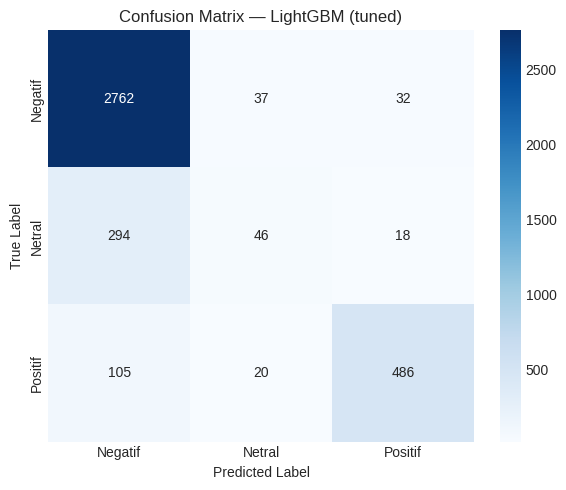

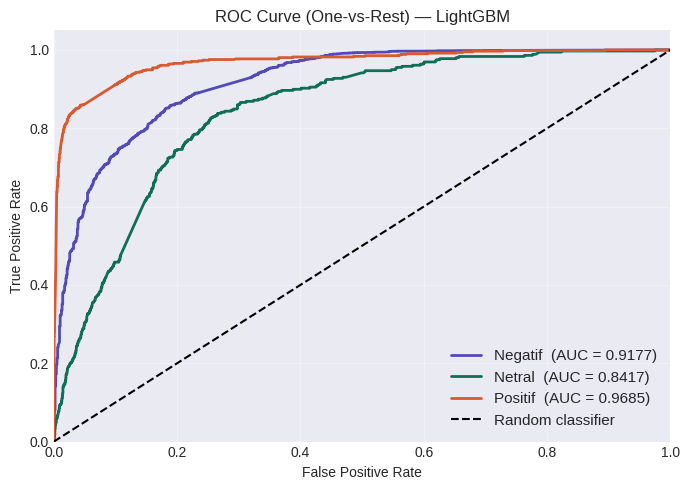

{'Negatif': np.float64(0.9177404885246966),
 'Netral': np.float64(0.8416756205791748),
 'Positif': np.float64(0.9684915772764294)}

In [111]:
plot_threshold_history(lgb_tuned["threshold_history"], "LightGBM")
plot_confusion_matrix(y_test, lgb_tuned["y_pred_tuned"], "LightGBM (tuned)", le.classes_)
plot_roc_curve(y_test, lgb_results["y_prob"], "LightGBM")

Hasil evaluasi model LightGBM (tuned) menunjukkan performa yang sangat baik dalam mengklasifikasikan kelas Negatif dan Positif, terlihat dari tingginya jumlah prediksi benar serta nilai AUC yang tinggi (Negatif = 0.9177, Positif = 0.9685). Namun, model masih kesulitan pada kelas Netral, yang sering salah diklasifikasikan sebagai negatif, sejalan dengan nilai AUC yang lebih rendah (0.8417). Hal ini mengindikasikan bahwa meskipun model memiliki kemampuan diskriminasi yang kuat secara keseluruhan, ketidakseimbangan data menyebabkan performa pada kelas minoritas, khususnya netral, masih belum optimal.

# Model 2 : SVM

In [115]:
# Untuk SVM, scaling diperlukan karena sensitive terhadap skala fitur
print("Standardisasi fitur untuk SVM...")
scaler = StandardScaler(with_mean=False)  # with_mean=False karena sparse matrix
X_train_scaled = scaler.fit_transform(X_train_tfidf)
X_test_scaled = scaler.transform(X_test_tfidf)

Standardisasi fitur untuk SVM...


In [116]:
# Parameter optimal untuk SVM (RBF kernel)
svm_params = {
    'C': 1.0,                    # Regularization
    'kernel': 'rbf',             # Radial Basis Function kernel
    'gamma': 'scale',            # Gamma otomatis
    'probability': True,         # Untuk probabilitas
    'random_state': 42,
    'cache_size': 1000           # Cache size untuk percepat
}

svm_model = SVC(**svm_params)

print("Training SVM...")
svm_model.fit(X_train_scaled, y_train)

Training SVM...


SVC(cache_size=1000, probability=True, random_state=42)

In [117]:
# Evaluasi SVM
svm_results = evaluate_model(svm_model, X_test_scaled, y_test, "SVM")


───────────────────────────────────────────────────────
  HASIL EVALUASI: SVM
───────────────────────────────────────────────────────
  Accuracy  : 0.8613  (86.13%)
  Precision : 0.8440  (weighted)
  Recall    : 0.8613  (weighted)
  F1-Score  : 0.8255  (weighted)

Classification Report:

              precision    recall  f1-score   support

     Negatif       0.86      0.99      0.92      2831
      Netral       0.65      0.06      0.11       358
     Positif       0.89      0.74      0.81       611

    accuracy                           0.86      3800
   macro avg       0.80      0.60      0.61      3800
weighted avg       0.84      0.86      0.83      3800



In [119]:
svm_tuned   = tune_threshold_multiclass(y_test, svm_results["y_prob"], "SVM")


  THRESHOLD TUNING: SVM
  Kelas 'Negatif     ' → threshold optimal: 0.47  (F1 = 0.8288)
  Kelas 'Netral      ' → threshold optimal: 0.12  (F1 = 0.8300)
  Kelas 'Positif     ' → threshold optimal: 0.58  (F1 = 0.8305)

  Threshold per kelas: {'Negatif': np.float64(0.47), 'Netral': np.float64(0.12), 'Positif': np.float64(0.58)}

  Hasil setelah tuning:
  Accuracy  : 0.8589  (85.89%)
  Precision : 0.8301  (weighted)
  Recall    : 0.8589  (weighted)
  F1-Score  : 0.8305  (weighted)

Classification Report (tuned):

              precision    recall  f1-score   support

     Negatif       0.86      0.98      0.92      2831
      Netral       0.46      0.11      0.17       358
     Positif       0.89      0.74      0.81       611

    accuracy                           0.86      3800
   macro avg       0.74      0.61      0.63      3800
weighted avg       0.83      0.86      0.83      3800



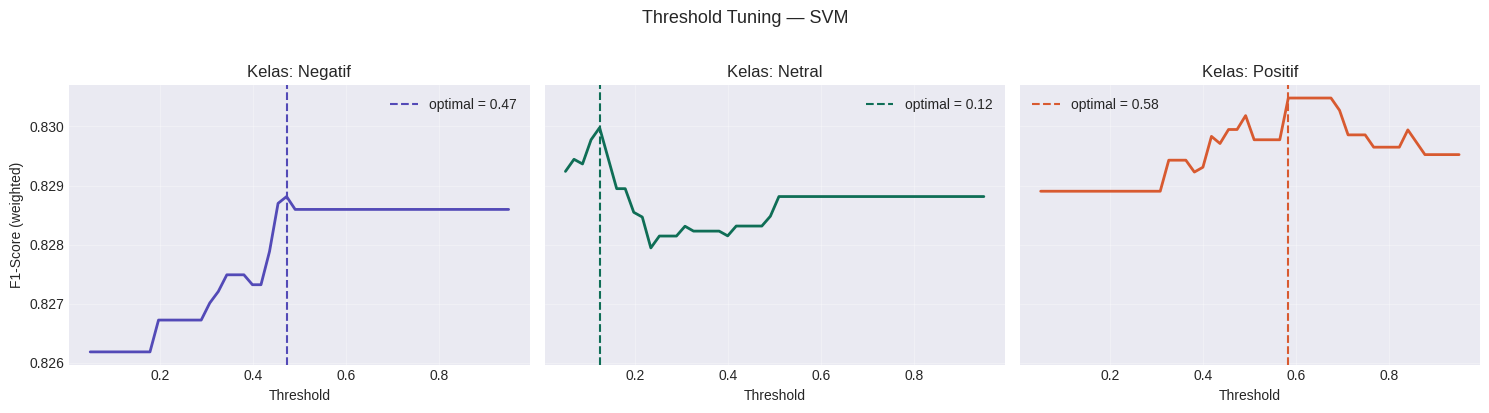

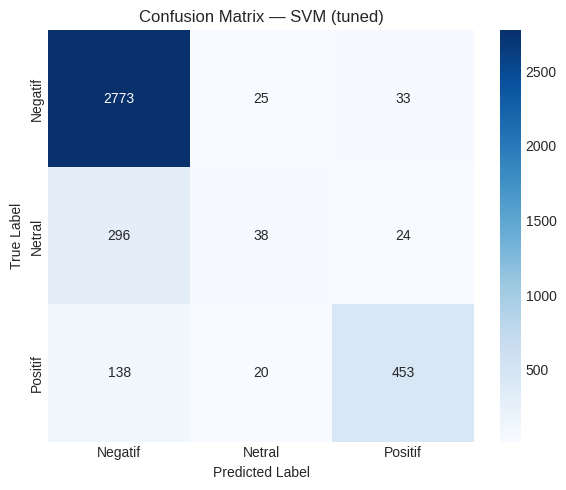

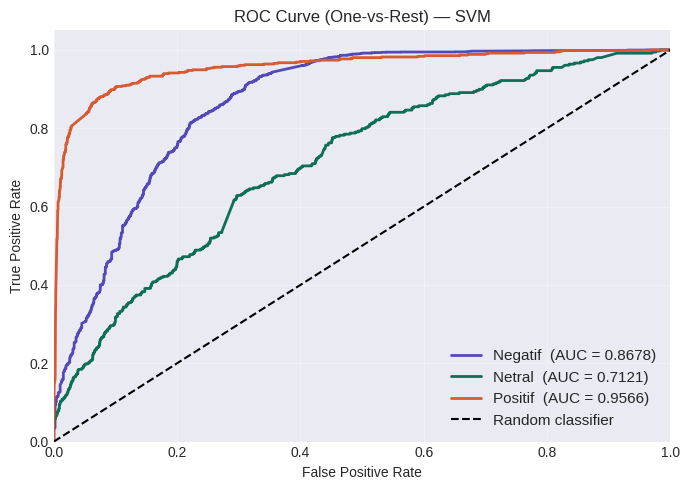

{'Negatif': np.float64(0.8677661698452084),
 'Netral': np.float64(0.7121265731564408),
 'Positif': np.float64(0.9566497765693137)}

In [120]:
plot_threshold_history(svm_tuned["threshold_history"], "SVM")
plot_confusion_matrix(y_test, svm_tuned["y_pred_tuned"], "SVM (tuned)", le.classes_)
plot_roc_curve(y_test, svm_results["y_prob"], "SVM")

Hasil evaluasi model SVM (tuned) menunjukkan performa yang cukup baik pada kelas Negatif dan Positif, dengan jumlah prediksi benar yang tinggi, namun masih terdapat kesalahan terutama dari kelas Positif dan Netral yang cenderung diklasifikasikan sebagai negatif. Performa pada kelas Netral menjadi yang paling lemah, terlihat dari rendahnya jumlah prediksi benar serta nilai AUC yang paling kecil (0.7121), dibandingkan dengan Negatif (0.8678) dan Positif (0.9566). Hal ini menunjukkan bahwa meskipun SVM mampu membedakan kelas mayoritas dan positif dengan cukup baik, model masih kesulitan dalam mengenali kelas minoritas, khususnya netral.

# Model 3 : MLP

In [121]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32), activation="relu",
    solver="adam", alpha=0.0001, batch_size=256,
    learning_rate="adaptive", learning_rate_init=0.001,
    max_iter=200, early_stopping=True, validation_fraction=0.1,
    n_iter_no_change=10, random_state=42, verbose=False
)

print("Training MLP...")
mlp_model.fit(X_train_tfidf, y_train)

Training MLP...


MLPClassifier(batch_size=256, early_stopping=True,
              hidden_layer_sizes=(128, 64, 32), learning_rate='adaptive',
              random_state=42)

In [122]:
mlp_results = evaluate_model(mlp_model, X_test_tfidf, y_test, "MLP")
mlp_tuned   = tune_threshold_multiclass(y_test, mlp_results["y_prob"], "MLP")


───────────────────────────────────────────────────────
  HASIL EVALUASI: MLP
───────────────────────────────────────────────────────
  Accuracy  : 0.8689  (86.89%)
  Precision : 0.8446  (weighted)
  Recall    : 0.8689  (weighted)
  F1-Score  : 0.8419  (weighted)

Classification Report:

              precision    recall  f1-score   support

     Negatif       0.88      0.97      0.92      2831
      Netral       0.55      0.12      0.19       358
     Positif       0.85      0.84      0.85       611

    accuracy                           0.87      3800
   macro avg       0.76      0.64      0.65      3800
weighted avg       0.84      0.87      0.84      3800


  THRESHOLD TUNING: MLP
  Kelas 'Negatif     ' → threshold optimal: 0.47  (F1 = 0.8419)
  Kelas 'Netral      ' → threshold optimal: 0.16  (F1 = 0.8505)
  Kelas 'Positif     ' → threshold optimal: 0.67  (F1 = 0.8511)

  Threshold per kelas: {'Negatif': np.float64(0.47), 'Netral': np.float64(0.16), 'Positif': np.float64(0.67)}



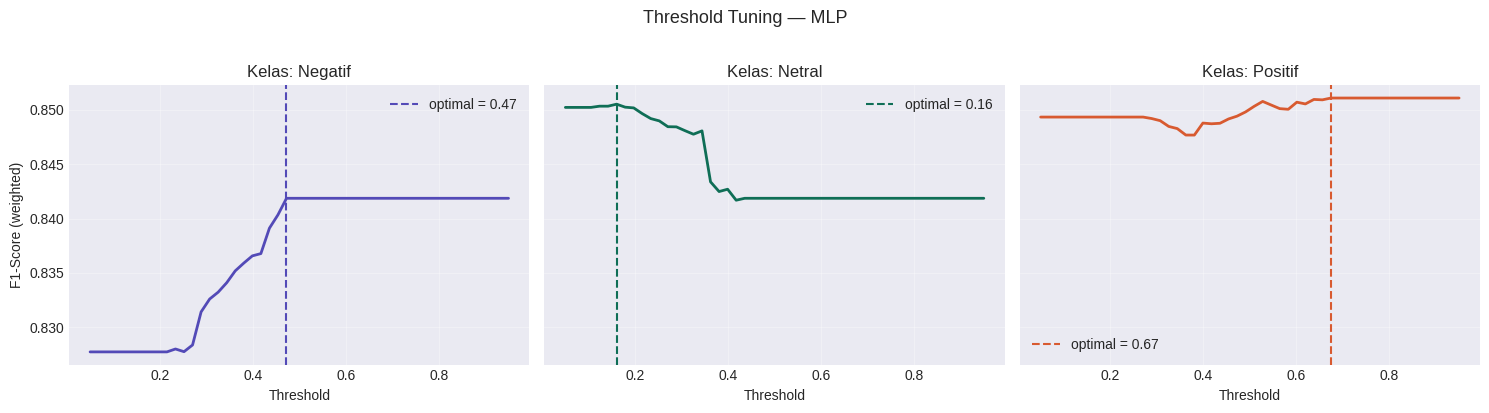

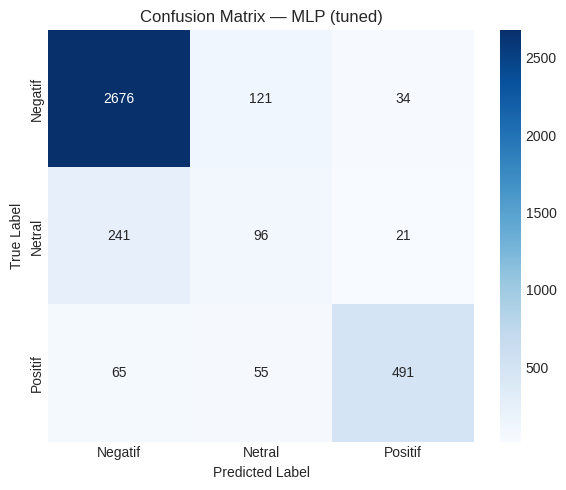

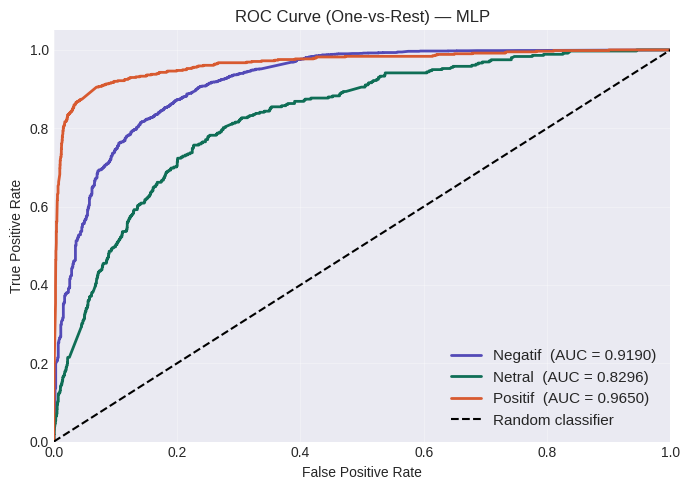

{'Negatif': np.float64(0.9190103377795373),
 'Netral': np.float64(0.8295586235104314),
 'Positif': np.float64(0.9650332387467352)}

In [123]:
plot_threshold_history(mlp_tuned["threshold_history"], "MLP")
plot_confusion_matrix(y_test, mlp_tuned["y_pred_tuned"], "MLP (tuned)", le.classes_)
plot_roc_curve(y_test, mlp_results["y_prob"], "MLP")

# Perbandingan model

In [124]:
records = []
for default, tuned in [
    (lgb_results, lgb_tuned),
    (svm_results, svm_tuned),
    (mlp_results, mlp_tuned),
]:
    records.append({
        "Model"         : default["name"],
        "Acc (default)" : round(default["accuracy"], 4),
        "F1 (default)"  : round(default["f1"], 4),
        "Acc (tuned)"   : round(tuned["accuracy"], 4),
        "F1 (tuned)"    : round(tuned["f1"], 4),
        "Δ F1"          : round(tuned["f1"] - default["f1"], 4),
        "Thresholds"    : tuned["optimal_thresholds"],
    })

recap_df = pd.DataFrame(records).set_index("Model")
print(recap_df.drop(columns="Thresholds").to_string())

          Acc (default)  F1 (default)  Acc (tuned)  F1 (tuned)    Δ F1
Model                                                                 
LightGBM         0.8661        0.8380       0.8668      0.8419  0.0038
SVM              0.8613        0.8255       0.8589      0.8305  0.0050
MLP              0.8689        0.8419       0.8587      0.8511  0.0092


In [126]:
print("\nThreshold optimal per model:")
for r in records:
    print(f"  {r['Model']:<12} → {r['Thresholds']}")


Threshold optimal per model:
  LightGBM     → {'Negatif': np.float64(0.47), 'Netral': np.float64(0.07), 'Positif': np.float64(0.49)}
  SVM          → {'Negatif': np.float64(0.47), 'Netral': np.float64(0.12), 'Positif': np.float64(0.58)}
  MLP          → {'Negatif': np.float64(0.47), 'Netral': np.float64(0.16), 'Positif': np.float64(0.67)}


In [127]:
# Model terbaik berdasarkan F1 tuned
best = max(records, key=lambda x: x["F1 (tuned)"])
print(f"\nModel terbaik (F1 tuned): {best['Model']}  "
      f"(F1 = {best['F1 (tuned)']:.4f})")


Model terbaik (F1 tuned): MLP  (F1 = 0.8511)


Berdasarkan hasil evaluasi TF-IDF, model MLP dengan threshold tuning merupakan yang terbaik dengan nilai F1-score tertinggi sebesar 0.8511, meskipun accuracy sedikit menurun. Hal ini menunjukkan bahwa penyesuaian threshold berhasil meningkatkan keseimbangan antara precision dan recall, terutama pada kondisi data yang tidak seimbang. Sementara itu, LightGBM dan SVM juga mengalami peningkatan performa setelah penyesuaian threshold, namun masih berada di bawah MLP dari sisi F1-score. Dengan demikian, MLP dengan threshold tuning dipilih sebagai model terbaik untuk representasi TF-IDF dalam penelitian ini.

# Save model terbaik

In [129]:
# Tentukan model terbaik berdasarkan F1 tuned
best_record = max(records, key=lambda x: x["F1 (tuned)"])
best_name   = best_record["Model"]

In [131]:
# Mapping nama model ke objek & hasil tuning
model_registry = {
    "LightGBM": (lgb_model, lgb_tuned, X_test_tfidf),
    "SVM"      : (svm_model, svm_tuned, X_test_scl),
    "MLP"      : (mlp_model, mlp_tuned, X_test_tfidf),
}

best_model_obj, best_tuned, _ = model_registry[best_name]
SAVE_DIR = "./model_sentimen_ovo_tfidf"
os.makedirs(SAVE_DIR, exist_ok=True)

In [ ]:
#  1. Simpan model 
joblib.dump(best_model_obj, f"{SAVE_DIR}/model.pkl")
print(f"  [OK] model.pkl")

#  2. Simpan TF-IDF vectorizer 
joblib.dump(tfidf, f"{SAVE_DIR}/tfidf_vectorizer.pkl")
print(f"  [OK] tfidf_vectorizer.pkl")

#  3. Simpan Label Encoder 
joblib.dump(le, f"{SAVE_DIR}/label_encoder.pkl")
print(f"  [OK] label_encoder.pkl")

#  4. Simpan StandardScaler (hanya jika model = SVM) 
if best_name == "SVM":
    joblib.dump(scaler, f"{SAVE_DIR}/scaler.pkl")
    print(f"  [OK] scaler.pkl  (dibutuhkan SVM)")
else:
    # Tulis file penanda bahwa scaler tidak dipakai
    with open(f"{SAVE_DIR}/scaler.pkl.skip", "w") as f:
        f.write("scaler tidak digunakan oleh model ini")
    print(f"  [--] scaler tidak diperlukan untuk {best_name}")

  [OK] model.pkl
  [OK] tfidf_vectorizer.pkl
  [OK] label_encoder.pkl
  [--] scaler tidak diperlukan untuk MLP


In [ ]:
# Simpan metadata & threshold optimal sebagai JSON 
metadata = {
    "model_name"         : best_name,
    "saved_at"           : datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "classes"            : le.classes_.tolist(),
    "optimal_thresholds" : best_tuned["optimal_thresholds"],
    "requires_scaler"    : best_name == "SVM",
    "tfidf_params": {
        "max_features" : tfidf.max_features,
        "ngram_range"  : list(tfidf.ngram_range),
        "sublinear_tf" : tfidf.sublinear_tf,
        "min_df"       : tfidf.min_df,
        "max_df"       : tfidf.max_df,
    },
    "metrics": {
        "accuracy"  : round(best_tuned["accuracy"], 4),
        "precision" : round(best_tuned["precision"], 4),
        "recall"    : round(best_tuned["recall"], 4),
        "f1_score"  : round(best_tuned["f1"], 4),
    }
}

with open(f"{SAVE_DIR}/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)
print(f"  [OK] metadata.json")

  [OK] metadata.json


In [ ]:
# Tampilkan ringkasan 
print(f"\n  Semua file tersimpan di: {SAVE_DIR}/")
print(f"  Threshold optimal: {best_tuned['optimal_thresholds']}")
print(f"  F1-Score (tuned) : {best_tuned['f1']:.4f}")

saved_files = os.listdir(SAVE_DIR)
print(f"\n  Isi folder:")
for f in sorted(saved_files):
    size = os.path.getsize(f"{SAVE_DIR}/{f}") / 1024
    print(f"    {f:<30} {size:>8.1f} KB")


  Semua file tersimpan di: ./model_sentimen_ovo_tfidf/
  Threshold optimal: {'Negatif': np.float64(0.47), 'Netral': np.float64(0.16), 'Positif': np.float64(0.67)}
  F1-Score (tuned) : 0.8511

  Isi folder:
    label_encoder.pkl                   0.5 KB
    metadata.json                       0.5 KB
    model.pkl                       15256.0 KB
    scaler.pkl.skip                     0.0 KB
    tfidf_vectorizer.pkl              197.4 KB
